In [14]:
#load the VAE model and check its performance
import sys
sys.path.append('C:\\Users\\SMest\\Dropbox\\nnGAN\\llm_test\\')
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np

import torch.nn as nn
import torch.optim as optim
from nnDS import nnDS, nnTokenizerPasthrough  # Import the nnDS dataset
from build_VAE_TOKEN import VanillaVAE
import umap
import matplotlib.pyplot as plt

In [15]:
#load the model
model = VanillaVAE(64, latent_dim=3).to('cuda')
model.load_state_dict(torch.load( 'vae_resp.pt'))

#load the data
data = nnDS("nn_ds_c.joblib", "nn_ds.joblib", 64, 64,  0, tokenizer=nnTokenizerPasthrough, dtype=torch.float32)  # Use nnDS dataset
dataloader = DataLoader(data, batch_size=128)
#check the performance
model.eval()

# #plot some samples
# for batch in dataloader:
#     batch = batch['past_values'].float()
#     for i in range(10):
#         sample_x = batch[i].unsqueeze(0)
#         gen = model.generate(sample_x).detach().cpu().numpy()
#         print(gen.shape)
#         plt.plot(gen[0])
       
#     #gen = model.generate(sample_x).detach().cpu().numpy()
#     #print(gen.shape)
#     #plt.plot(gen[0])


VanillaVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=64, out_features=512, bias=True)
      (1): Dropout(p=0.3, inplace=False)
      (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): Dropout(p=0.3, inplace=False)
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): Dropout(p=0.3, inplace=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Dropout(p=0.3, inplace=False)
      (2): BatchNorm1d(64, eps=1e-05, mom

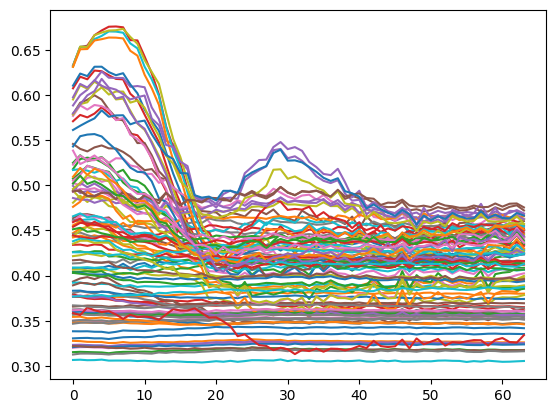

In [16]:
samples = model.sample(100, 'cuda').cpu().detach().numpy()
for s in samples:
    plt.plot(s)

In [17]:
#plot the latent space
data_loader = DataLoader(data, batch_size=512, shuffle=True)
latent = []
#get the max value of the data in the dataset
maxes = []
recons = []
data= []
for i, batch in enumerate(data_loader):
    batch = batch['past_values'].to('cuda')
    latents =model.reparameterize( *model.encode(batch))
    latents_h = latents.detach().cpu().numpy()
    latent.append(latents_h)
    maxes.append(batch.cpu().numpy())

    if i < 1:
        #grab the reconstructions
        recon = model.generate(batch)
        recons.append(recon.detach().cpu().numpy())
        data.append(batch.cpu().numpy())


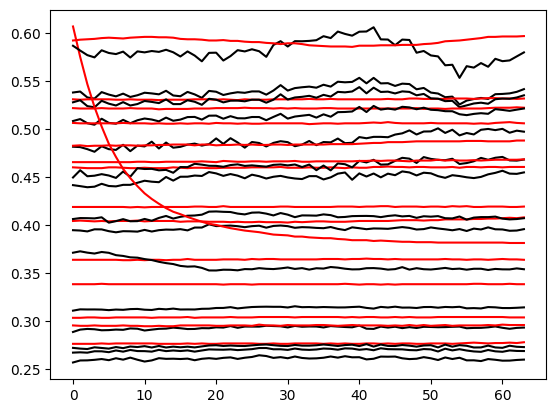

In [19]:
#plot the reconstructions
for d, r in zip(data, recons):
    for i, s in zip(d[:15], r[:15]):
        plt.plot(s, c='k')
        plt.plot(i,c='r')

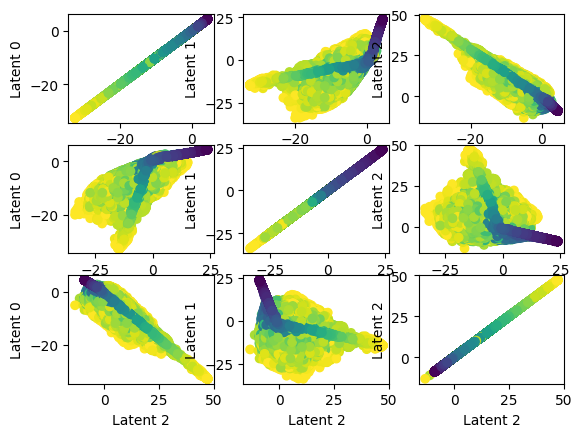

In [8]:
latent = np.vstack(latent)
maxes = np.vstack(maxes)
rowwise_max = np.max(maxes, axis=1)
#plot the first two dimensions
ax_grid = plt.subplots(3,3)
for i in range(3):
    for j in range(3):
        ax = ax_grid[1][i][j]
        ax.scatter(latent[:,i], latent[:,j], c=rowwise_max)
        ax.set_xlabel(f'Latent {i}')
        ax.set_ylabel(f'Latent {j}')


Text(0.5, 0, 'Latent 2')

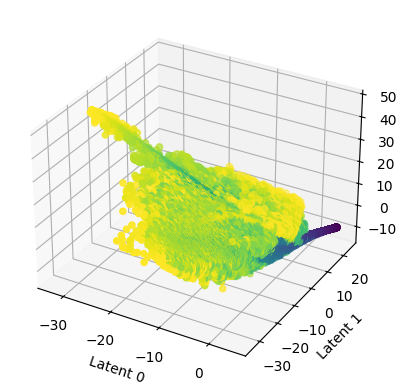

In [9]:
#3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(latent[:,0], latent[:,1], latent[:,2], c=rowwise_max)
ax.set_xlabel('Latent 0')
ax.set_ylabel('Latent 1')
ax.set_zlabel('Latent 2')
#make interactive